In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Defence thesis/Pre Defense /questionnaire.csv")
df

,Gender,University,Age,Type_of_Residence,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Internet_At_Home,In_Relationship,Relationship_Satisfaction,Family_Relationships,Overall_Health,Bullying_Frequency,PartTime_Job,Absences_Semester,Average_CGPA,CGPA_Satisfaction
0,M,DIU,23.0,U,GT3,A,1,0,Housewife,Farmer,...,Yes,No,NaN,5.0,5.0,Never,No,2.0,3.28,3.0
1,M,DIU,24.0,R,GT3,A,3,4,Housewife,Teacher,...,Yes,No,NaN,5.0,4.0,Rarely,No,0.0,3.71,4.0
2,F,DIU,19.0,R,GT3,A,2,2,Housewife,Farmer,...,Yes,No,NaN,1.0,3.0,Never,No,2.0,NaN,3.0
3,M,DIU,24.0,U,GT3,A,1,3,Housewife,Govt Job,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M,DIU,23.0,U,GT3,A,4,4,Housewife,Businessman,...,Yes,Yes,4.0,5.0,3.0,Never,Yes,NaN,3.49,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,M,DIU,24.0,R,GT3,A,4,4,Housewife,Govt job,...,Yes,No,NaN,5.0,2.0,Rarely,No,2.0,3.58,1.0
495,M,DIU,25.0,R,LE3,A,4,4,Teacher,Teacher,...,Yes,No,NaN,5.0,3.0,Never,No,5.0,3.12,3.0
496,M,DIU,25.0,U,GT3,T,4,4,Housewife,Dead,...,Yes,No,5.0,5.0,1.0,Always,No,4.0,NaN,3.0
497,M,JKKNIU,19.0,R,GT3,A,0,0,Housewife,Farmer,...,No,No,1.0,5.0,3.0,Never,No,2.0,NaN,4.0


In [4]:
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
object_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in object_cols:
   df_clean[col] = df_clean[col].astype(str).str.strip()

for col in object_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')

df = df_clean

/tmp/ipython-input-1523556729.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')


In [5]:
df.columns

Index(['Gender', 'University', 'Age', 'Type_of_Residence', 'Family_Size',
       'Parental_Status', 'Mother_Education', 'Father_Education', 'Mother_Job',
       'Father_Job', 'Primary_Guardian', 'Motivation_Level',
       'University_Selection_Method', 'University_Choice_Reason',
       'Program_Choice_Personal', 'Program_Satisfaction_Level',
       'Living_Arrangement', 'Travel_Time_', 'Study_Hours_Per_Week',
       'Failed_Classes', 'Num_Failed_Classes', 'Extra_Support_University',
       'Changed_Major', 'Reason_Changed_Major', 'Considered_Dropout',
       'Reason_Considered_Dropout', 'Adjustment_Issues',
       'Adjustment_Difficulty', 'Stress_Frequency', 'Made_Friends',
       'Hangout_Frequency', 'Social_Activity_Frequency',
       'Extracurricular_Participation', 'Free_Time', 'Classmate_Cooperation',
       'Mentor_Support', 'Internet_At_Home', 'In_Relationship',
       'Relationship_Satisfaction', 'Family_Relationships', 'Overall_Health',
       'Bullying_Frequency', 'PartTime_

In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
Num_Failed_Classes,231
Relationship_Satisfaction,207
Absences_Semester,7
Travel_Time_,6
Age,4
CGPA_Satisfaction,2
Adjustment_Difficulty,1
Study_Hours_Per_Week,1
Hangout_Frequency,1
Overall_Health,1


In [7]:
df.loc[df['Considered_Dropout'] == 'No', 'Reason_Considered_Dropout'] = None
df.loc[df['In_Relationship'] == 'No', 'Relationship_Satisfaction'] = None
df.loc[df['Changed_Major'] == 'No', 'Reason_Changed_Major'] = None
df.loc[df['Failed_Classes'] == 'No', 'Num_Failed_Classes'] = 0

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
Reason_Changed_Major,435
Reason_Considered_Dropout,394
Relationship_Satisfaction,336
Num_Failed_Classes,9
Absences_Semester,7
Travel_Time_,6
Age,4
CGPA_Satisfaction,2
Study_Hours_Per_Week,1
Hangout_Frequency,1


In [9]:
df.dtypes

,0
Gender,object
University,object
Age,float64
Type_of_Residence,object
Family_Size,object
Parental_Status,object
Mother_Education,int64
Father_Education,int64
Mother_Job,object
Father_Job,object


In [10]:
cols = [
    'Reason_Changed_Major',
    'Reason_Considered_Dropout',
    'Relationship_Satisfaction'
]

for col in df.columns:

    if col not in cols:

        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)

        elif pd.api.types.is_object_dtype(df[col]):
            mode_val = df[col].mode(dropna=True)[0]
            df[col] = df[col].fillna(mode_val)

    else:
        df[col] = df[col].fillna('Not_Applicable')


In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
Gender,0
University,0
Age,0
Type_of_Residence,0
Family_Size,0
Parental_Status,0
Mother_Education,0
Father_Education,0
Mother_Job,0
Father_Job,0


In [12]:
with pd.option_context('display.max_rows', None):
    print(df[['Reason_Changed_Major', 'Reason_Considered_Dropout', 'Relationship_Satisfaction']])

                             Reason_Changed_Major  \
0                                  Not_Applicable   
1                                  Not_Applicable   
2                                  Not_Applicable   
3                                             nan   
4                                  Not_Applicable   
5                                  Not_Applicable   
6                                  Not_Applicable   
7                                  Not_Applicable   
8                                  Not_Applicable   
9                                  Not_Applicable   
10         Lack of interest in the original major   
11                                 Not_Applicable   
12                                 Not_Applicable   
13                                 Not_Applicable   
14                                 Not_Applicable   
15                                 Not_Applicable   
16                                 Not_Applicable   
17                                 Not_Applica

In [13]:
df['Relationship_Satisfaction'] = df['Relationship_Satisfaction'].replace('Not_Applicable', 0)
df['Relationship_Satisfaction'] = df['Relationship_Satisfaction'].astype(float)

/tmp/ipython-input-48760170.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Relationship_Satisfaction'] = df['Relationship_Satisfaction'].replace('Not_Applicable', 0)


In [14]:
df = df.drop(['University','Reason_Considered_Dropout'], axis=1)

In [15]:
df['Average_CGPA'].dtype

dtype('O')

In [16]:
df['Average_CGPA'] = pd.to_numeric(df['Average_CGPA'], errors='coerce')
df['Average_CGPA'] = df['Average_CGPA'].fillna(df['Average_CGPA'].median())
df['Average_CGPA'].dtype

dtype('float64')

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import shap

In [18]:
X = df.drop(['Considered_Dropout'], axis=1)
y = df['Considered_Dropout']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
nominal_cols = ['Gender','Type_of_Residence', 'Family_Size', 'Parental_Status',
                'Mother_Job', 'Father_Job', 'Primary_Guardian', 'University_Selection_Method',
                'University_Choice_Reason', 'Program_Choice_Personal', 'Living_Arrangement',
                'Failed_Classes', 'Extra_Support_University', 'Changed_Major', 'Reason_Changed_Major',
                'Adjustment_Issues', 'Stress_Frequency', 'Made_Friends', 'Social_Activity_Frequency',
                'Extracurricular_Participation', 'Internet_At_Home', 'In_Relationship',
                'Bullying_Frequency', 'PartTime_Job']

numeric_cols = ['Age','Num_Failed_Classes','Travel_Time_','Absences_Semester','Average_CGPA']

ordinal_cols = ['Mother_Education','Father_Education','Motivation_Level','Program_Satisfaction_Level',
                'Study_Hours_Per_Week','Adjustment_Difficulty','Hangout_Frequency','Free_Time',
                'Classmate_Cooperation','Mentor_Support','Family_Relationships','Relationship_Satisfaction',
                'Overall_Health','CGPA_Satisfaction']

In [20]:
def outliers(X):
    X = np.array(X, dtype=float)
    X_out = X.copy()
    for i in range(X.shape[1]):
        col = X[:, i]
        Q1 = np.percentile(col, 25)
        Q3 = np.percentile(col, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        median = np.median(col)
        col = np.where(col < lower, median, col)
        col = np.where(col > upper, median, col)
        X_out[:, i] = col
    return X_out

outlier_transformer = FunctionTransformer(outliers, validate=True)

In [21]:
from sklearn.preprocessing import OrdinalEncoder


num_pipeline = Pipeline([
    ('outlier', outlier_transformer),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('num', num_pipeline, numeric_cols),
    ('ord', OrdinalEncoder(), ordinal_cols)
])
preprocessor.fit(X_train)

ohe_cols = preprocessor.named_transformers_['nom'].get_feature_names_out().shape[0]
num_cols = len(numeric_cols)
ord_cols = len(ordinal_cols)

categorical_indices = (
    list(range(0, ohe_cols)) +
    list(range(ohe_cols + num_cols, ohe_cols + num_cols + ord_cols))
)

X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)


if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()


ohe = preprocessor.named_transformers_['nom']
ohe_features = ohe.get_feature_names_out(nominal_cols)
feature_names = list(ohe_features) + list(numeric_cols) + list(ordinal_cols)


X_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)
X_test_trans = pd.DataFrame(X_test_trans, columns=feature_names)


nan_cols = [col for col in X_train_trans.columns if col.endswith('_nan')]
X_train_trans = X_train_trans.drop(columns=nan_cols)
X_test_trans = X_test_trans.drop(columns=nan_cols)


feature_names = X_train_trans.columns.tolist()

In [22]:
print(y_train.value_counts())

Considered_Dropout
No     308
Yes     91
Name: count, dtype: int64


In [23]:
ohe_features = ohe.get_feature_names_out(nominal_cols)
categorical_indices = [i for i, f in enumerate(feature_names) if f in ohe_features]


if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()


from imblearn.over_sampling import SMOTENC

sm = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_bal, y_train_bal = sm.fit_resample(X_train_trans, y_train)

In [24]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bal)
y_test_enc  = le.transform(y_test)

print("Shapes:", X_train_bal.shape, X_test_trans.shape)
print("Label classes:", list(le.classes_))

Shapes: (616, 169) (100, 169)
Label classes: ['No', 'Yes']


In [26]:
X_train_bal_df = pd.DataFrame(X_train_bal, columns=feature_names)
X_train_bal_df = X_train_bal_df.apply(pd.to_numeric, errors='coerce').fillna(X_train_bal_df.median(numeric_only=True))

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        max_depth=5,
        learning_rate=0.1,
        n_estimators=300,
        eval_metric='logloss',
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        depth=6,
        iterations=300,
        learning_rate=0.1,
        verbose=0,
        random_state=42
    )
}

fitted_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_bal_df, y_train_enc)
    fitted_models[name] = model

for name, model in fitted_models.items():
    print(f"\n------ {name} ------")
    y_pred = model.predict(X_test_trans)
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


Training Decision Tree...

Training Random Forest...

Training XGBoost...

Training CatBoost...

------ Decision Tree ------
              precision    recall  f1-score   support

          No       0.92      0.79      0.85        86
         Yes       0.31      0.57      0.40        14

    accuracy                           0.76       100
   macro avg       0.61      0.68      0.62       100
weighted avg       0.83      0.76      0.79       100


------ Random Forest ------
              precision    recall  f1-score   support

          No       0.89      0.94      0.92        86
         Yes       0.44      0.29      0.35        14

    accuracy                           0.85       100
   macro avg       0.67      0.61      0.63       100
weighted avg       0.83      0.85      0.84       100


------ XGBoost ------
              precision    recall  f1-score   support

          No       0.91      0.92      0.91        86
         Yes       0.46      0.43      0.44        14

    

In [49]:
X_train_bal_df = pd.DataFrame(X_train_bal, columns=feature_names)
X_train_bal_df = X_train_bal_df.apply(pd.to_numeric, errors='coerce').fillna(X_train_bal_df.median(numeric_only=True))
X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)

In [29]:
print("NaNs in y_train_enc:", np.isnan(y_train_enc).sum())
print("NaNs in X_train_bal:", np.isnan(X_train_bal).sum())

NaNs in y_train_enc: 0
NaNs in X_train_bal: Gender_F                     0
Gender_M                     0
Type_of_Residence_R          0
Type_of_Residence_U          0
Family_Size_GT3              0
                            ..
Mentor_Support               0
Family_Relationships         0
Relationship_Satisfaction    0
Overall_Health               0
CGPA_Satisfaction            0
Length: 169, dtype: int64


In [30]:
feature_importances = {}
for name, model in models.items():
    model.fit(X_train_bal_df, y_train_enc)
    if hasattr(model, "feature_importances_"):
        feature_importances[name] = model.feature_importances_
    elif hasattr(model, "get_feature_importance"):
        feature_importances[name] = model.get_feature_importance()
    else:
        print(f"{name}: No feature_importances_ or get_feature_importance() found")

features = X_train_bal_df.columns

norm_importances = {
    name: imp / np.sum(imp)
    for name, imp in feature_importances.items()
}

df_importance = pd.DataFrame(norm_importances, index=features)

df_importance['mean_rank'] = df_importance.rank(ascending=False).mean(axis=1)
df_importance = df_importance.sort_values('mean_rank')

top_common = df_importance.head(20)
print("\nTop 20 Common Important Features Across Models (mean rank method):\n")
print(top_common)


Top 20 Common Important Features Across Models (mean rank method):

                                          Decision Tree  Random Forest  \
Classmate_Cooperation                          0.119687       0.042142   
Adjustment_Difficulty                          0.079521       0.041007   
Overall_Health                                 0.046552       0.035550   
Relationship_Satisfaction                      0.053448       0.029120   
Age                                            0.018853       0.031433   
Motivation_Level                               0.081226       0.026575   
Father_Education                               0.077219       0.019885   
CGPA_Satisfaction                              0.015584       0.028761   
Stress_Frequency_Often                         0.051036       0.012067   
Stress_Frequency_Rarely                        0.026610       0.012206   
Free_Time                                      0.026092       0.023834   
Mentor_Support                             

In [31]:
summary = pd.DataFrame({
    'Top_MeanRank_Features': pd.Series(top_common.index.tolist())
})

print("\n===== Summary Table for Thesis =====\n")
print(summary)


===== Summary Table for Thesis =====

                       Top_MeanRank_Features
0                      Classmate_Cooperation
1                      Adjustment_Difficulty
2                             Overall_Health
3                  Relationship_Satisfaction
4                                        Age
5                           Motivation_Level
6                           Father_Education
7                          CGPA_Satisfaction
8                     Stress_Frequency_Often
9                    Stress_Frequency_Rarely
10                                 Free_Time
11                            Mentor_Support
12                         Hangout_Frequency
13                              Travel_Time_
14                Program_Satisfaction_Level
15                                  Gender_F
16                              Average_CGPA
17         Adjustment_Issues_No major issues
18                      Study_Hours_Per_Week
19  Living_Arrangement_Private accommodation


In [32]:
from pprint import pprint
selected_features = summary['Top_MeanRank_Features'].tolist()

print(f"\nTraining models with {len(selected_features)} selected features:")
pprint(selected_features)


Training models with 20 selected features:
['Classmate_Cooperation',
 'Adjustment_Difficulty',
 'Overall_Health',
 'Relationship_Satisfaction',
 'Age',
 'Motivation_Level',
 'Father_Education',
 'CGPA_Satisfaction',
 'Stress_Frequency_Often',
 'Stress_Frequency_Rarely',
 'Free_Time',
 'Mentor_Support',
 'Hangout_Frequency',
 'Travel_Time_',
 'Program_Satisfaction_Level',
 'Gender_F',
 'Average_CGPA',
 'Adjustment_Issues_No major issues',
 'Study_Hours_Per_Week',
 'Living_Arrangement_Private accommodation']


In [33]:
X_train_selected = X_train_bal_df[selected_features]
X_test_selected = X_test_df[selected_features]

In [34]:
from sklearn.metrics import accuracy_score

models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),

    }

results = []

for name, model in models.items():
    model.fit(X_train_selected, y_train_enc)
    y_pred = model.predict(X_test_selected)

    acc = accuracy_score(y_test_enc, y_pred)
    results.append({'Model': name, 'Accuracy': acc})


results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\n===== Model Performance Summary (Selected Features) =====")
print(results_df)


===== Model Performance Summary (Selected Features) =====
          Model  Accuracy
1  RandomForest      0.87
3       XGBoost      0.82
2      CatBoost      0.81
0  DecisionTree      0.74


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau, f_oneway


print("===== FEATURE IMPORTANCE ANALYSIS =====\n")

# --- Descriptive Statistics ---
desc_stats = df_importance.describe().T
print(desc_stats)

===== FEATURE IMPORTANCE ANALYSIS =====

               count       mean        std  min        25%        50%  \
Decision Tree  169.0   0.005917   0.016360  0.0   0.000000   0.000000   
Random Forest  169.0   0.005917   0.009705  0.0   0.000162   0.001117   
XGBoost        169.0   0.005917   0.010641  0.0   0.000000   0.000000   
CatBoost       169.0   0.005917   0.012674  0.0   0.000000   0.000106   
mean_rank      169.0  85.000000  39.058335  3.0  56.250000  94.250000   

                      75%         max  
Decision Tree    0.003059    0.119687  
Random Forest    0.006153    0.042142  
XGBoost          0.007474    0.052742  
CatBoost         0.004419    0.075005  
mean_rank      121.125000  133.000000  


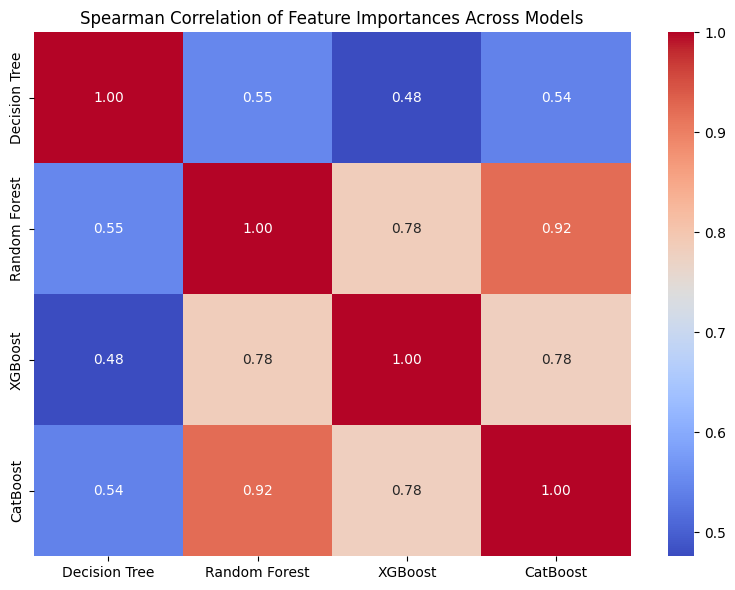

In [36]:
# --- Feature Importance Correlation Across Models ---
model_cols = [col for col in df_importance.columns if col not in ["mean_rank"]]
correlation_matrix = df_importance[model_cols].corr(method='spearman')


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation of Feature Importances Across Models")
plt.tight_layout()
plt.show()

In [37]:
# --- Statistical Tests: Spearman & Kendall ---
print("\n===== Rank Correlation Between Models =====")
for i, m1 in enumerate(model_cols):
  for m2 in model_cols[i+1:]:
    rho, _ = spearmanr(df_importance[m1], df_importance[m2])
    tau, _ = kendalltau(df_importance[m1], df_importance[m2])
    print(f"{m1} vs {m2}: Spearman={rho:.3f}, Kendall={tau:.3f}")


# --- Top Features Visualization ---
print("\n===== TOP COMMON FEATURES =====\n")
top_features = df_importance.head(20)
print(top_features)


===== Rank Correlation Between Models =====
Decision Tree vs Random Forest: Spearman=0.548, Kendall=0.436
Decision Tree vs XGBoost: Spearman=0.476, Kendall=0.412
Decision Tree vs CatBoost: Spearman=0.542, Kendall=0.449
Random Forest vs XGBoost: Spearman=0.784, Kendall=0.596
Random Forest vs CatBoost: Spearman=0.921, Kendall=0.790
XGBoost vs CatBoost: Spearman=0.780, Kendall=0.625

===== TOP COMMON FEATURES =====

                                          Decision Tree  Random Forest  \
Classmate_Cooperation                          0.119687       0.042142   
Adjustment_Difficulty                          0.079521       0.041007   
Overall_Health                                 0.046552       0.035550   
Relationship_Satisfaction                      0.053448       0.029120   
Age                                            0.018853       0.031433   
Motivation_Level                               0.081226       0.026575   
Father_Education                               0.077219       0.

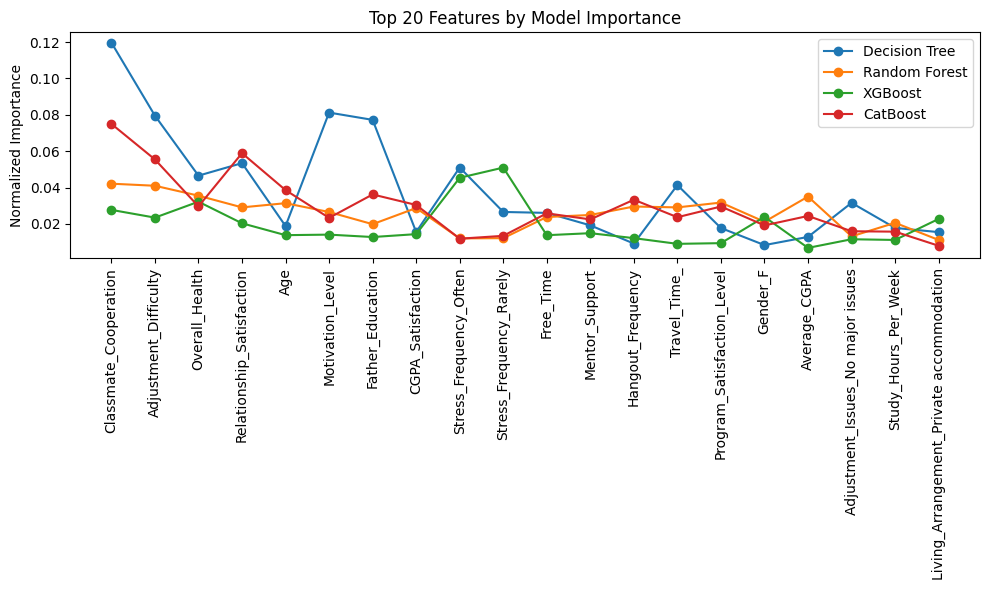

In [38]:
plt.figure(figsize=(10, 6))
for col in model_cols:
    plt.plot(top_features.index, top_features[col], marker='o', label=col)
plt.xticks(rotation=90)
plt.title("Top 20 Features by Model Importance")
plt.ylabel("Normalized Importance")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-3765787421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


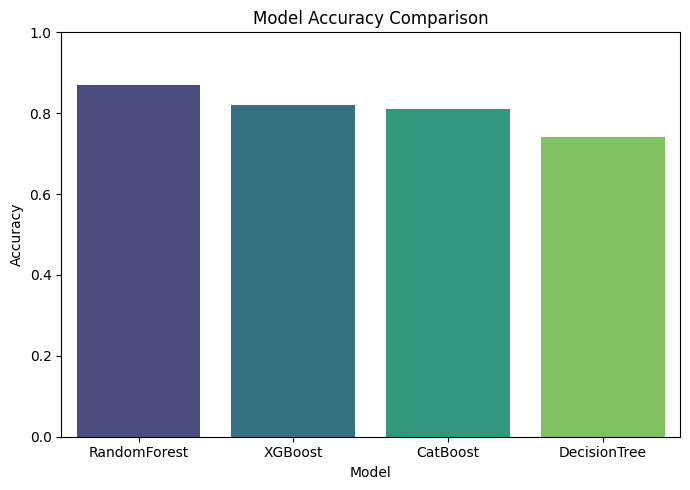

In [39]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [46]:
rank_summary = pd.DataFrame({
'Feature': df_importance.index,
'Mean Rank': df_importance['mean_rank'],
'Rank StdDev': df_importance[model_cols].rank(ascending=False).std(axis=1)
}).sort_values('Mean Rank')

In [47]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_selected, y_train_enc, cv=5, scoring='accuracy')
    results[name] = scores
    print(f"{name}: mean={scores.mean():.3f}, std={scores.std():.3f}")


DecisionTree: mean=0.817, std=0.078
RandomForest: mean=0.887, std=0.096
XGBoost: mean=0.854, std=0.081
CatBoost: mean=0.890, std=0.077


In [48]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(
    results["DecisionTree"],
    results["RandomForest"],
    results["XGBoost"],
    results["CatBoost"]
)
print(f"Friedman test p-value = {p:.4f}")

Friedman test p-value = 0.0050


In [44]:
from scipy.stats import ttest_rel

for other in ["DecisionTree", "XGBoost", "CatBoost"]:
    t, p = ttest_rel(results["RandomForest"], results[other])
    print(f"RandomForest vs {other}: p={p:.4f}")

RandomForest vs DecisionTree: p=0.0109
RandomForest vs XGBoost: p=0.0440
RandomForest vs CatBoost: p=0.7749
